# Computational Thermofluid Dynamics - Chapter 3

Technical University of Munich, Professur für Thermofluiddynamik - Pr. Polifke

Created: 04/2024 | J. Yao, N. Garcia, G. Varillon

Revised: 10/2025 | A. Keles

==============================================================================================

# Stage 1 – Boundary Derivation
For the **South–West corner node**, write first the general finite volume equation in the same form as Eq. (A.14), including all surface contributions.

Then, impose the **Neumann condition** on the South boundary and the **Dirichlet condition** on the West boundary.  
For the remaining faces, apply Green’s theorem as shown in *Appendix A.2.1*.

Present only the resulting expressions in the same style as Eqs. (A.15)–(A.20) in addition to the boundary conditions, without repeating the detailed integration steps.

Write your solutions in LateX format here


$$\int_{S^P} \lambda \nabla^2 TdS = \oint_{\partial S^P} \lambda\nabla T \cdot n dl = 0 $$

$$\lambda \nabla^2 TdS \approx \frac{1}{S^P} \frac{}{} \oint_{\partial S^P} \lambda\nabla T \cdot n dl = 0 $$


$$ \frac{}{} \oint_{\partial S^P} \lambda\nabla T \cdot n dl = \left[\int_{ls} \nabla T \cdot n_s dl + \int_{le}\nabla T \cdot n_e dl + \int_{ln}\nabla T \cdot n_n dl + \int_{lw}\nabla T \cdot n_w dl  \right] = 0 $$

Applying the midpoint rule:
$$ (\nabla T |_P \cdot n_s) l_P^e + (\nabla T |_P \cdot n_w) l_n^P + \left(\frac{dT}{dx}|_{\eta e}\Delta y_e^{ne} - \frac{dT}{dy} |_{\eta e}\Delta x_e^{ne}  \right) + \left(\frac{dT}{dx}|_{n \epsilon}\Delta y_{ne}^{n} - \frac{dT}{dy} |_{n \epsilon}\Delta x_{ne}^{n}  \right) = 0 $$

$$ -\dot{q} l_P^e + (\nabla T |_P \cdot n_w) l_{nP}^P + \left(\frac{dT}{dx}|_{\eta e}\Delta y_e^{ne} - \frac{dT}{dy} |_{\eta e}\Delta x_e^{ne}  \right) + \left(\frac{dT}{dx}|_{n \epsilon}\Delta y_{ne}^{n} - \frac{dT}{dy} |_{n \epsilon}\Delta x_{ne}^{n}  \right) = 0 $$

$$\frac{dT}{dx}|_{\eta e} = \frac{1}{S^{\eta e}} \left[ \Delta y_P^{E} T|_{e} + \Delta y_E^{nE} T|_{\eta E} + 
\Delta y_{nE}^{nP} T|_{n e} + \Delta y_{nP}^{P} T|_{\eta P}  \right] $$ 
$$\frac{dT}{dy}|_{\eta e} = \frac{1}{S^{\eta e}} \left[ \Delta x_P^{E} T|_{e} + \Delta x_E^{nE} T|_{\eta E} + 
\Delta x_{nE}^{nP} T|_{n e} + \Delta x_{nP}^{P} T|_{\eta P}  \right] $$ 

$$\frac{dT}{dx}|_{n \epsilon} = \frac{1}{S^{n \epsilon}} \left[ \Delta y_P^{e} T|_{\epsilon} + \Delta y_e^{Ne} T|_{ne} + 
\Delta y_{Ne}^{NP} T|_{N \epsilon} + \Delta y_{NP}^{P} T|_{n P}  \right] $$ 
$$\frac{dT}{dy}|_{n \epsilon} = \frac{1}{S^{n \epsilon}} \left[ \Delta x_P^{e} T|_{\epsilon} + \Delta x_e^{Ne} T|_{ne} + 
\Delta x_{Ne}^{NP} T|_{N \epsilon} + \Delta x_{NP}^{P} T|_{n P}  \right] $$ 

$$T_e = \frac{T_P + T_E}{2}$$
$$T_{\eta E} = \frac{T_E + T_{nE}}{2}$$
$$T_{nE} = \frac{T_E + T_N}{2}$$
$$T_{ne} = \frac{T_e + T_{NE}}{2}$$
$$T_{\eta P} = T_D$$
$$T_{nP} = T_D$$


# Stage 2 – Solver Implementation

In this stage, you will implement a **2D steady-state heat conduction solver** using the Finite Volume Method (FVM) with all boundary condition types.

The **form function** defining the geometry is already provided — do **not** modify it.  
Your task starts from the **mesh generation** using `setupMesh()`.  
First, **visualize the mesh** to verify that the geometry and node layout are correct.

Next, complete the helper class and functions:
- `Coordinate2D` class  
- `calculate_area`, `dx`, `dy`, `dist`, and `index` functions  
Refer to the provided Skriptum for the necessary geometric and differential relations.

In the **main solver class**:
1. Initialize all required parameters similarly to the Finite Difference (FD) exercise.  
2. In the `set_stencil()` method, identify whether each node belongs to the interior, boundary, or corner region, and call the respective `build_*()` function.  
   - `build_inner()` and `build_north()` are already implemented as examples.  
   - You must implement the remaining boundary and corner functions yourself.

Inside the `solve()` method:
- Loop through each node in the computational domain.  
- Call `set_stencil()` for each node to assemble the global coefficient matrix **A** and source vector **B**.  
- After assembly, solve the linear system and reshape the resulting temperature field into 2D form.

Finally, visualize the computed temperature field using the provided plotting routine.  
Note that you are solving only the **upper half** of the geometry.  
Reconstruct the full domain for plotting using `np.flipud()` and `np.vstack()` to mirror the field across the symmetry line.


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm

## Form function to change the shape of domain
![Domain](domain.png)
see Figure 3.4


In [ ]:
def formfunction(x, shape):
    """
    Defines the shape of north boundary
    takes an array and shape
    returns an array
    """
    h1 = x[-1]           # west boundary height
    h2 = x[-1] / 10 * 4  # east boundary height
    l  = x[-1]           # domain length
    if shape == 'linear':
        m = (h2 - h1) / (2 * l)
        b = h1 / 2
        return m * x + b
    
    elif shape == 'rectangular':
        return l * np.ones((x.size, 1))
        
    elif shape == 'quadratic':
        k = 2 * l**2 / (h1 - h2)
        return (x - l)**2 / k + h2 / 2 
    
    elif shape == 'crazy':
        return h1/2 + (h2/2 - h1/2) * x / l + 0.25*(-h1 + h2/2) * np.sin(np.pi*x/l)**2
    
    else:
        raise ValueError('Unknown shape: %s' % shape)

def setUpMesh(nodes_x, nodes_y, length, formfunction, shape):
    # X - matrix of x coordinates
    # Y - matrix of y coordinates
    X = np.linspace(0, length, nodes_x)
    # Y cooridnates of the northern boundary
    north_shape = formfunction(X, shape)
    Y = np.ones((nodes_x, nodes_y))
    for j in np.arange(nodes_y):
        Y[:, j] = np.linspace(north_shape[j], 0, nodes_y)
        
    X = np.ones((nodes_x, nodes_y)) * X
    
    return X , Y

In [10]:
# if you fail to implement linear, go with rectangular case!
shape =  'crazy'    # 'rectangular', 'linear',  'quadratic', 'crazy'

l = 1
dimX = 51
dimY = 51

boundary =   ['D', 'N', 'D', 'D'] # [N,S,W,E] : D : Dirichlet, N : Neumann, R : Robin
TD =  [100 , 100 , 300 , 100] # [N,S,W,E]
alpha = 20
Tinf = 90
q = 0

X, Y = setUpMesh(dimX, dimY, l, formfunction, shape)


Displaying Figure 1: Mesh Gridlines


(0.0, 0.55)

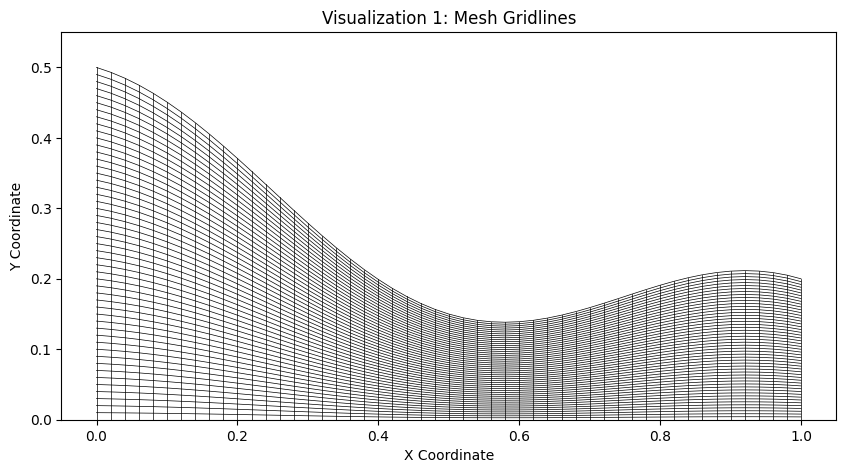

In [11]:
print("Displaying Figure 1: Mesh Gridlines")
fig1, ax1 = plt.subplots(figsize=(10, 6))

# Matplotlib's plot() function is smart:
# - plot(X, Y) plots all columns of X against all columns of Y.
# - plot(X.T, Y.T) plots all rows (transposed to be columns)

# Plot the "vertical" mesh lines (columns)
ax1.plot(X, Y, color='black', lw=0.5)
# Plot the "horizontal" mesh lines (rows)
ax1.plot(X.T, Y.T, color='black', lw=0.5)

# Set plot properties
ax1.set_title('Visualization 1: Mesh Gridlines')
ax1.set_xlabel('X Coordinate')
ax1.set_ylabel('Y Coordinate')
# Using 'equal' aspect ratio is crucial for seeing the mesh's true shape
ax1.set_aspect('equal')
ax1.set_ylim(0, np.max(Y) * 1.1) # Add some padding

In [ ]:
class Coordinate2D():
    def __init__(self, x, y):
        self.x = x
        self.y = y

def calculate_area(ul, bl, br, ur):
    # calculate the area of the cell
    # ul (upper left), bl (bottom left), br (bottom right), ur (upper right) are the coordinates of the four vertices of the cell
    # apply Gaussian trapezoidal formula to calculate the areas
    area = 0.5 * ((ur.x * br.y - br.x * ur.y) + (br.x * bl.y - bl.x * br.y) + 
                  (bl.x * ul.y - ul.x * bl.y) + (ul.x * ur.y - ur.x * ul.y))
    return area

def dy(a, b):
    # Calculate distance between 'a' and 'b' along the y axis
    return b.y - a.y
    
def dx(a, b):
    # Calculate distance between 'a' and 'b' along the x axis
    return b.x - a.x
    
def dist(a, b):
    # Calculate the euclidean distance between 'a' and 'b'
    return np.sqrt((b.x - a.x)**2 + (b.y - a.y)**2)

def index(i, j):
    # Return the index in the computational vector based on the physical indices 'i', 'j' and dimX (global parameter)
    return i * dimY + j # Might be wrong
    

In [ ]:
class SteadyHeat2D_FVM():
    def __init__(self, X, Y, boundary=[], TD=[], q=0.0, alpha=0.0, Tinf=0.0):
        # i, j is the index of the cell
        # X, Y is the mesh
        # boundary is the boundary condition: "R", "D", "N"
        # TD is the Dirichlet Temperature
        # q is the heat flux
        # alpha is the heat transfer coefficient
        # Tinf is the temperature of the surrounding

        self.X = X
        self.Y = Y
        self.boundary = boundary
        self.TD = TD
        self.q = q
        self.alpha = alpha
        self.Tinf = Tinf

        # n is the number of points in the first direction
        # m is the number of points in the second direction
        self.n, self.m = X.shape
        # m -> y or i , n -> x or j

        self.A = np.ones((self.n*self.m, self.n*self.m))
        self.B = np.ones(self.n*self.m)
        
    def set_stencil(self, i, j):
        # Based on 'i','j' decide if the node is inner or boundary (which boundary?)
        if (j < (self.n - 1)) and (i < (self.m - 1)):
            self.build_inner()
        elif (i == (self.m - 1)) and (j > 0) and (j < (self.n - 1)):
            self.build_south()
        elif (i == 0) and (j > 0) and (j < (self.n - 1)):
            self.build_north()
        elif (j == (self.n - 1)) and (i > 0) and (i < (self.m - 1)):
            self.build_east()
        elif (j == 0) and (i > 0) and (i < (self.m - 1)):
            self.build_west()
        elif (j == (self.n - 1)) and (i == (self.m - 1)):
            self.build_SE()
        elif (j == 0) and (i == (self.m - 1)):
            self.build_SW()
        elif (j == (self.n - 1)) and (i == 0):
            self.build_NE()
        elif (j == 0) and (i == 0):
            self.build_NW()
    

    def build_inner(self, i, j):
        stencil = np.zeros(self.n*self.m)
        b = np.zeros(1)
        # % Nomenclature:
        # %
        # %    NW(i-1,j-1)   Nw -  N(i-1,j) -  Ne     NE(i-1,j+1)
        # %
        # %                 |                 |
        # %
        # %       nW - - - - nw ------ n ------ ne - - - nE
        # %                 |                 |
        # %       |         |        |        |       |
        # %                 |                 |
        # %   W(i, j-1) - - w - - P (i,j) - - e - -  E (i,j+1)
        # %                 |                 |
        # %       |         |        |        |       |
        # %                 |                 |
        # %      sW - - - - sw ------ s ------ se - - - sE
        # %
        # %                 |                 |
        # %
        # %   SW(i+1,j-1)   Sw  -  S(i+1,j)  - Se      SE(i+1,j+1)
        # %
        # % Indexing of stencil: 

        # %    D_4 - D_1 - D2
        # %     |     |     | 
        # %    D_3 - D_0 - D3
        # %     |     |     | 
        # %    D_2 -  D1 - D4
        
        # First coordinate is in the real x direction, and the second in the y direction, however 
        # changing the index i (first one) changes the point up or down and the j (second one) left and right
        
        # principle node coordinate
        P = Coordinate2D(self.X[i, j], self.Y[i, j])
        N = Coordinate2D(self.X[i-1, j], self.Y[i-1, j])
        S = Coordinate2D(self.X[i+1, j], self.Y[i+1, j])
        W = Coordinate2D(self.X[i, j-1], self.Y[i, j-1])
        E = Coordinate2D(self.X[i, j+1], self.Y[i, j+1])
        NW = Coordinate2D(self.X[i-1, j-1], self.Y[i-1, j-1])
        NE = Coordinate2D(self.X[i-1, j+1], self.Y[i-1, j+1])
        SW = Coordinate2D(self.X[i+1, j-1], self.Y[i+1, j-1])
        SE = Coordinate2D(self.X[i+1, j+1], self.Y[i+1, j+1])

        # auxiliary node coordinate
        Nw = Coordinate2D((N.x + NW.x)/2, (N.y + NW.y)/2)
        Ne = Coordinate2D((N.x + NE.x)/2, (N.y + NE.y)/2)
        Sw = Coordinate2D((S.x + SW.x)/2, (S.y + SW.y)/2)
        Se = Coordinate2D((S.x + SE.x)/2, (S.y + SE.y)/2)
        nW = Coordinate2D((W.x + NW.x)/2, (W.y + NW.y)/2)
        nE = Coordinate2D((E.x + NE.x)/2, (E.y + NE.y)/2)
        sW = Coordinate2D((W.x + SW.x)/2, (W.y + SW.y)/2)
        sE = Coordinate2D((E.x + SE.x)/2, (E.y + SE.y)/2)

        n = Coordinate2D((N.x + P.x)/2, (N.y + P.y)/2)
        s = Coordinate2D((S.x + P.x)/2, (S.y + P.y)/2)
        w = Coordinate2D((W.x + P.x)/2, (W.y + P.y)/2)
        e = Coordinate2D((E.x + P.x)/2, (E.y + P.y)/2)

        se = Coordinate2D((Se.x + e.x)/2, (Se.y + e.y)/2)
        sw = Coordinate2D((Sw.x + w.x)/2, (Sw.y + w.y)/2)
        ne = Coordinate2D((Ne.x + e.x)/2, (Ne.y + e.y)/2)
        nw = Coordinate2D((Nw.x + w.x)/2, (Nw.y + w.y)/2)
        
        # calculate the area of the cell
        S_P = calculate_area(ne, se, sw, nw)
        S_n = calculate_area(Ne, e, w, Nw)
        S_s = calculate_area(e, Se, Sw, w)
        S_w = calculate_area(n, s, sW, nW)
        S_e = calculate_area(nE, sE, s, n)

        D3 = ((dx(se, ne) * (dx(nE, n)/4 + dx(s, sE)/4 + dx(sE, nE))) / S_e + 
             (dy(se, ne) * (dy(nE, n)/4 + dy(s, sE)/4 + dy(sE, nE))) / S_e + 
             (dx(e, Ne) * dx(ne, nw)) / (4*S_n) + (dx(Se,e) * dx(sw,se)) / (4*S_s) + 
             (dy(e, Ne) * dy(ne, nw)) / (4*S_n) + (dy(Se,e) * dy(sw,se)) / (4*S_s)) / S_P
        D_3 = ((dx(nw, sw) * (dx(n, nW) / 4 + dx(sW, s) / 4 + dx(nW, sW))) / S_w +
              (dy(nw, sw) * (dy(n, nW) / 4 + dy(sW, s) / 4 + dy(nW, sW))) / S_w +
              (dx(Nw, w) * dx(ne, nw)) / (4 * S_n) +
              (dx(w, Sw) * dx(sw, se)) / (4 * S_s) +
              (dy(Nw, w) * dy(ne, nw)) / (4 * S_n) +
              (dy(w, Sw) * dy(sw, se)) / (4 * S_s)) / S_P
        D1 = ((dx(sw, se) * (dx(Se, e) / 4 + dx(w, Sw) / 4 + dx(Sw, Se))) / S_s +
            (dy(sw, se) * (dy(Se, e) / 4 + dy(w, Sw) / 4 + dy(Sw, Se))) / S_s +
            (dx(s, sE) * dx(se, ne)) / (4 * S_e) +
            (dx(sW, s) * dx(nw, sw)) / (4 * S_w) +
            (dy(s, sE) * dy(se, ne)) / (4 * S_e) +
            (dy(sW, s) * dy(nw, sw)) / (4 * S_w)) / S_P
        # North
        D_1 = ((dx(ne, nw) * (dx(e, Ne) / 4 + dx(Nw, w) / 4 + dx(Ne, Nw))) / S_n +
            (dy(ne, nw) * (dy(e, Ne) / 4 + dy(Nw, w) / 4 + dy(Ne, Nw))) / S_n +
            (dx(nE, n) * dx(se, ne)) / (4 * S_e) +
            (dx(n, nW) * dx(nw, sw)) / (4 * S_w) +
            (dy(nE, n) * dy(se, ne)) / (4 * S_e) +
            (dy(n, nW) * dy(nw, sw)) / (4 * S_w)) / S_P

        # NW
        D_4 = ((dx(Nw, w) * dx(ne, nw)) / (4 * S_n) +
            (dx(n, nW) * dx(nw, sw)) / (4 * S_w) +
            (dy(Nw, w) * dy(ne, nw)) / (4 * S_n) +
            (dy(n, nW) * dy(nw, sw)) / (4 * S_w)) / S_P

        # NE
        D2 = ((dx(nE, n) * dx(se, ne)) / (4 * S_e) +
            (dx(e, Ne) * dx(ne, nw)) / (4 * S_n) +
            (dy(nE, n) * dy(se, ne)) / (4 * S_e) +
            (dy(e, Ne) * dy(ne, nw)) / (4 * S_n)) / S_P

        # SW
        D_2 = ((dx(w, Sw) * dx(sw, se)) / (4 * S_s) +
            (dx(sW, s) * dx(nw, sw)) / (4 * S_w) +
            (dy(w, Sw) * dy(sw, se)) / (4 * S_s) +
            (dy(sW, s) * dy(nw, sw)) / (4 * S_w)) / S_P

        # SE
        D4 = ((dx(s, sE) * dx(se, ne)) / (4 * S_e) +
            (dx(Se, e) * dx(sw, se)) / (4 * S_s) +
            (dy(s, sE) * dy(se, ne)) / (4 * S_e) +
            (dy(Se, e) * dy(sw, se)) / (4 * S_s)) / S_P

        # Center (P)
        D0 = ((dx(se, ne) * (dx(n, s) + dx(nE, n) / 4 + dx(s, sE) / 4)) / S_e +
            (dx(ne, nw) * (dx(w, e) + dx(e, Ne) / 4 + dx(Nw, w) / 4)) / S_n +
            (dx(sw, se) * (dx(e, w) + dx(Se, e) / 4 + dx(w, Sw) / 4)) / S_s +
            (dx(nw, sw) * (dx(s, n) + dx(n, nW) / 4 + dx(sW, s) / 4)) / S_w +
            (dy(se, ne) * (dy(n, s) + dy(nE, n) / 4 + dy(s, sE) / 4)) / S_e +
            (dy(ne, nw) * (dy(w, e) + dy(e, Ne) / 4 + dy(Nw, w) / 4)) / S_n +
            (dy(sw, se) * (dy(e, w) + dy(Se, e) / 4 + dy(w, Sw) / 4)) / S_s +
            (dy(nw, sw) * (dy(s, n) + dy(n, nW) / 4 + dy(sW, s) / 4)) / S_w) / S_P
        
        stencil[index(i, j)] = D0
        stencil[index(i-1, j)] = D_1
        stencil[index(i+1, j)] = D1
        stencil[index(i, j-1)] = D_3
        stencil[index(i, j+1)] = D3
        stencil[index(i-1, j-1)] = D_4
        stencil[index(i-1, j+1)] = D2
        stencil[index(i+1, j-1)] = D_2
        stencil[index(i+1, j+1)] = D4
        
        return stencil,b
        
    
    def build_north(self, i, j):
        stencil = np.zeros(self.n*self.m)
        b = np.zeros(1)
        if self.boundary[0] == 'D':
            stencil[index(i, j)] = 1.0
            b = self.TD[0]
        else: 
            # principle node coordinate
            P = Coordinate2D(self.X[i, j], self.Y[i, j])
            S = Coordinate2D(self.X[i+1, j], self.Y[i+1, j])
            W = Coordinate2D(self.X[i, j-1], self.Y[i, j-1])
            E = Coordinate2D(self.X[i, j+1], self.Y[i, j+1])
            SW = Coordinate2D(self.X[i+1, j-1], self.Y[i+1, j-1])
            SE = Coordinate2D(self.X[i+1, j+1], self.Y[i+1, j+1])

            # auxiliary node coordinate
            Sw = Coordinate2D((S.x + SW.x)/2, (S.y + SW.y)/2)
            Se = Coordinate2D((S.x + SE.x)/2, (S.y + SE.y)/2)
            sW = Coordinate2D((W.x + SW.x)/2, (W.y + SW.y)/2)
            sE = Coordinate2D((E.x + SE.x)/2, (E.y + SE.y)/2)

            s = Coordinate2D((S.x + P.x)/2, (S.y + P.y)/2)
            w = Coordinate2D((W.x + P.x)/2, (W.y + P.y)/2)
            e = Coordinate2D((E.x + P.x)/2, (E.y + P.y)/2)

            se = Coordinate2D((Se.x + e.x)/2, (Se.y + e.y)/2)
            sw = Coordinate2D((Sw.x + w.x)/2, (Sw.y + w.y)/2)

            # calculate the area of the cell
            S_ss = calculate_area(e, se, sw, w)
            S_s = calculate_area(e, Se, Sw, w)
            S_ssw = calculate_area(P, s, sW, W)
            S_sse = calculate_area(E, sE, s, P)

            # East
            D3 = (dy(sw, se) * (dy(Se, e) / 4) / S_s + dx(sw, se) * (dx(Se, e) / 4) / S_s +
                dy(se, e) * (dy(s, sE) / 4 + 3 * dy(sE, E) / 4 + dy(E, P) / 2) / S_sse +
                dx(se, e) * (dx(s, sE) / 4 + 3 * dx(sE, E) / 4 + dx(E, P) / 2) / S_sse) / S_ss

            # West
            D_3 = (dy(w, sw) * (3 * dy(W, sW) / 4 + dy(sW, s) / 4 + dy(P, W) / 2) / S_ssw +
                dx(w, sw) * (3 * dx(W, sW) / 4 + dx(sW, s) / 4 + dx(P, W) / 2) / S_ssw +
                dy(sw, se) * (dy(w, Sw) / 4) / S_s + dx(sw, se) * (dx(w, Sw) / 4) / S_s) / S_ss

            # South
            D1 = (dy(w, sw) * (dy(sW, s) / 4 + dy(s, P) / 4) / S_ssw +
                dx(w, sw) * (dx(sW, s) / 4 + dx(s, P) / 4) / S_ssw +
                dy(sw, se) * (dy(w, Sw) / 4 + dy(Sw, Se) + dy(Se, e) / 4) / S_s +
                dx(sw, se) * (dx(w, Sw) / 4 + dx(Sw, Se) + dx(Se, e) / 4) / S_s +
                dy(se, e) * (dy(P, s) / 4 + dy(s, sE) / 4) / S_sse +
                dx(se, e) * (dx(P, s) / 4 + dx(s, sE) / 4) / S_sse) / S_ss

            # SW
            D_2 = (dy(w, sw) * (dy(W, sW) / 4 + dy(sW, s) / 4) / S_ssw +
                dx(w, sw) * (dx(W, sW) / 4 + dx(sW, s) / 4) / S_ssw +
                dy(sw, se) * (dy(w, Sw) / 4) / S_s + dx(sw, se) * (dx(w, Sw) / 4) / S_s) / S_ss

            # SE
            D4 = (dy(sw, se) * (dy(Se, e) / 4) / S_s + dx(sw, se) * (dx(Se, e) / 4) / S_s +
                dy(se, e) * (dy(s, sE) / 4 + dy(sE, E) / 4) / S_sse +
                dx(se, e) * (dx(s, sE) / 4 + dx(sE, E) / 4) / S_sse) / S_ss
            
            coefficient = 0.0
            if self.boundary[0] == 'N':
                coefficient = 0.0
                b = self.q * dist(e, w) / S_ss
            elif self.boundary[0] == 'R':
                coefficient = - self.alpha
                b = - self.alpha * self.Tinf * dist(e, w) / S_ss
            else:
                raise ValueError('Unknown boundary type: %s' % boundary[0])
            
            D0 = (coefficient * dist(e, w) +
                dy(w, sw) * (dy(sW, s) / 4 + 3 * dy(s, P) / 4 + dy(P, W) / 2) / S_ssw +
                dx(w, sw) * (dx(sW, s) / 4 + 3 * dx(s, P) / 4 + dx(P, W) / 2) / S_ssw +
                dy(sw, se) * (dy(w, Sw) / 4 + dy(Se, e) / 4 + dy(e, w)) / S_s +
                dx(sw, se) * (dx(w, Sw) / 4 + dx(Se, e) / 4 + dx(e, w)) / S_s +
                dy(se, e) * (3 * dy(P, s) / 4 + dy(s, sE) / 4 + dy(E, P) / 2) / S_sse +
                dx(se, e) * (3 * dx(P, s) / 4 + dx(s, sE) / 4 + dx(E, P) / 2) / S_sse) / S_ss
            
            stencil[index(i, j)] = D0
            stencil[index(i+1, j)] = D1
            stencil[index(i, j-1)] = D_3
            stencil[index(i, j+1)] = D3
            stencil[index(i+1, j-1)] = D_2
            stencil[index(i+1, j+1)] = D4

        return stencil,b
    
    def build_south(self, i, j):
        
    
    def build_west(self, i, j):
        
    
    def build_east(self, i, j):
        
    
    def build_NW(self, i, j):
        
    
    def build_NE(self, i, j):
        
    
    def build_SW(self, i, j):
        
    
    def build_SE(self, i, j):
        
    
    def solve(self):
        return T
    
    def plot_Result(self, T, plot_type = "2D"):
        # Create a 2D and 3D plots
        pass

SyntaxError: invalid syntax (1962596164.py, line 21)

# Stage 3 - Test Cases

In [ ]:
# if you fail to implement linear, go with rectangular case!
shape =  'linear'    # 'rectangular', 'linear',  'quadratic', 'crazy'

l = 1
dimX = 51
dimY = 51

boundary =   ['D', 'N', 'D', 'D'] # [N,S,W,E] : D : Dirichlet, N : Neumann, R : Robin
TD =  [100 , 100 , 300 , 100] # [N,S,W,E]
alpha = 20
Tinf = 90
q = 0

X, Y = setUpMesh(dimX, dimY, l, formfunction, shape)
heat = SteadyHeat2D_FVM(X, Y, boundary, TD, q, alpha, Tinf)
T = heat.solve()
heat.plot_Result(T, "2D")
heat.plot_Result(T, "3D")

In [ ]:
# if you fail to implement linear, go with rectangular case!
shape =  'linear'    # 'rectangular', 'linear',  'quadratic', 'crazy'

l = 1
dimX = 51
dimY = 51

boundary =   ['R', 'N', 'D', 'R'] # [N,S,W,E] : D : Dirichlet, N : Neumann, R : Robin
TD =  [100 , 100 , 100 , 100] # [N,S,W,E]
alpha = 20
Tinf = 90
q = 0

X, Y = setUpMesh(dimX, dimY, l, formfunction, shape)
heat = SteadyHeat2D_FVM(X, Y, boundary, TD, q, alpha, Tinf)
T = heat.solve()
heat.plot_Result(T, "2D")
heat.plot_Result(T, "3D")

In [ ]:
# if you fail to implement linear, go with rectangular case!
shape =  'linear'    # 'rectangular', 'linear',  'quadratic', 'crazy'

l = 1
dimX = 81
dimY = 51

boundary =   ['R', 'N', 'D', 'R'] # [N,S,W,E] : D : Dirichlet, N : Neumann, R : Robin
TD =  [100 , 100 , 100 , 100] # [N,S,W,E]
alpha = 20
Tinf = 90
q = 0

X, Y = setUpMesh(dimX, dimY, l, formfunction, shape)
heat = SteadyHeat2D_FVM(X, Y, boundary, TD, q, alpha, Tinf)
T = heat.solve()
heat.plot_Result(T, "2D")
heat.plot_Result(T, "3D")